# Investigating Attention Drift and Prediction Stability in CNNs

This notebook demonstrates how different data augmentation strengths influence:
- Training dynamics
- Prediction stability
- Spatial attention behaviour using Grad-CAM

Dataset: CIFAR-10  
Backbone: MobileNetV2 (Transfer Learning)

## 1. Import Libraries

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

## 3. Create Training Subset

In [ ]:
subset_size = 10000

x_train_small = x_train[:subset_size]
y_train_small = y_train[:subset_size]

## 4. Preprocessing Pipeline

In [ ]:
IMG_SIZE = 96

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

In [ ]:
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
train_ds = train_ds.map(preprocess).shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 5. Define Baseline Model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)

model_baseline = tf.keras.Model(inputs=base_model.input, outputs=output)

model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_baseline.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Train Baseline Model

In [ ]:
EPOCHS = 8

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 163s 967ms/step - accuracy: 0.5080 - loss: 1.4634 - val_accuracy: 0.7074 - val_loss: 0.8829
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 145s 919ms/step - accuracy: 0.6822 - loss: 0.9352 - val_accuracy: 0.7398 - val_loss: 0.7714
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 823ms/step - accuracy: 0.7182 - loss: 0.8128 - val_accuracy: 0.7557 - val_loss: 0.7162
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 134s 770ms/step - accuracy: 0.7501 - loss: 0.7315 - val_accuracy: 0.7642 - val_loss: 0.6817
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 140s 888ms/step - accuracy: 0.7674 - loss: 0.6702 - val_accuracy: 0.7641 - val_loss: 0.6777
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 896ms/step - accuracy: 0.7878 - loss: 0.6227 - val_accuracy: 0.7711 - val_loss: 0.6564
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 892ms/step - accuracy: 0.7955 - loss: 0.5951 - val_accuracy: 0.7800 - val_loss: 0.6415
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 140s 889ms/step - accuracy: 0.8099 - loss: 0

## 7. Visualise Training Performance

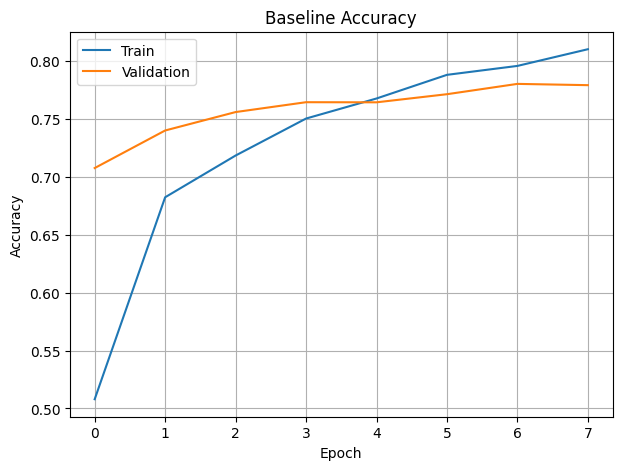

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(history_baseline.history["accuracy"])
plt.plot(history_baseline.history["val_accuracy"])

plt.title("Baseline Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.grid()

plt.show()

The baseline model shows stable convergence with steady validation improvement.
This suggests that without augmentation, feature learning remains consistent under transfer learning constraints.

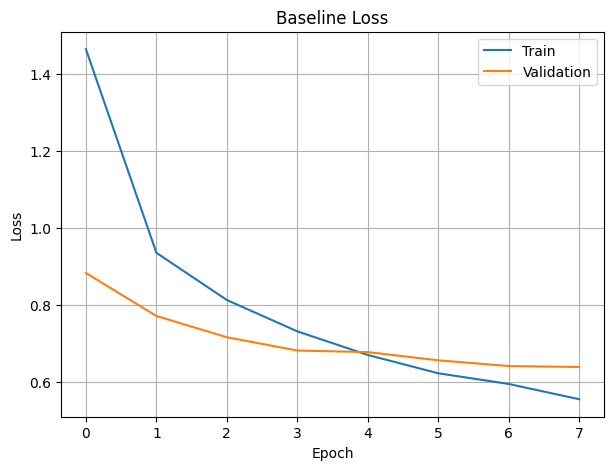

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(history_baseline.history["loss"])
plt.plot(history_baseline.history["val_loss"])

plt.title("Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.grid()

plt.show()

Loss trends indicate limited overfitting, supporting the effectiveness of frozen backbone features.

In [ ]:
test_loss, test_acc = model_baseline.evaluate(test_ds)

print("Baseline Test Accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 394ms/step - accuracy: 0.7789 - loss: 0.6390
Baseline Test Accuracy: 0.7789000272750854


In [ ]:
model_baseline.save("baseline_mobilenet.h5")

In [ ]:
plt.savefig("baseline_accuracy.png")

<Figure size 640x480 with 0 Axes>

## 8. Preprocessing Pipeline MODERATE AUGMENTATION

In [ ]:
data_aug_moderate = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
def preprocess_moderate(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    image = data_aug_moderate(image)
    return image, label

In [ ]:
train_mod = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
train_mod = train_mod.map(preprocess_moderate).shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 9. Define Baseline Model

In [ ]:
base_model2 = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model2.trainable = False

x = base_model2.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)

model_mod = tf.keras.Model(inputs=base_model2.input, outputs=output)

model_mod.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 10. Train Baseline Model

In [ ]:
history_mod = model_mod.fit(
    train_mod,
    validation_data=test_ds,
    epochs=8
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.4198 - loss: 1.6861 - val_accuracy: 0.6526 - val_loss: 1.0386
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 163s 954ms/step - accuracy: 0.5850 - loss: 1.2103 - val_accuracy: 0.6940 - val_loss: 0.9003
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 164s 953ms/step - accuracy: 0.6324 - loss: 1.0793 - val_accuracy: 0.7234 - val_loss: 0.8035
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 164s 955ms/step - accuracy: 0.6534 - loss: 0.9948 - val_accuracy: 0.7401 - val_loss: 0.7566
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 140s 799ms/step - accuracy: 0.6712 - loss: 0.9436 - val_accuracy: 0.7466 - val_loss: 0.7482
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 165s 963ms/step - accuracy: 0.6824 - loss: 0.9155 - val_accuracy: 0.7465 - val_loss: 0.7304
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 811ms/step - accuracy: 0.7004 - loss: 0.8672 - val_accuracy: 0.7493 - val_loss: 0.7243
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 164s 954ms/step - accuracy: 0.7064 - loss: 0.85

In [ ]:
model_mod.save("moderate_aug_model.h5")

## 11. Preprocessing Pipeline AGGRESSIVE AUGMENTATION

In [ ]:
data_aug_aggressive = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.20),
    tf.keras.layers.RandomZoom(0.30),
    tf.keras.layers.RandomContrast(0.30),
    tf.keras.layers.GaussianNoise(0.10)
])

In [ ]:
def preprocess_aggressive(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    image = data_aug_aggressive(image)
    return image, label

In [ ]:
train_agg = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
train_agg = train_agg.map(preprocess_aggressive).shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 12. Define Baseline Model

In [ ]:
base_model3 = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model3.trainable = False

x = base_model3.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)

model_agg = tf.keras.Model(inputs=base_model3.input, outputs=output)

model_agg.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 13. Train Baseline Model

In [ ]:
history_agg = model_agg.fit(
    train_agg,
    validation_data=test_ds,
    epochs=8
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 151s 816ms/step - accuracy: 0.3191 - loss: 1.9405 - val_accuracy: 0.5865 - val_loss: 1.2574
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 167s 959ms/step - accuracy: 0.4511 - loss: 1.5473 - val_accuracy: 0.6307 - val_loss: 1.0840
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 205s 976ms/step - accuracy: 0.4864 - loss: 1.4440 - val_accuracy: 0.6638 - val_loss: 0.9869
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 199s 959ms/step - accuracy: 0.5121 - loss: 1.3786 - val_accuracy: 0.6826 - val_loss: 0.9314
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 167s 966ms/step - accuracy: 0.5294 - loss: 1.3384 - val_accuracy: 0.6846 - val_loss: 0.9271
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 166s 964ms/step - accuracy: 0.5516 - loss: 1.2871 - val_accuracy: 0.7010 - val_loss: 0.8735
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 147s 839ms/step - accuracy: 0.5546 - loss: 1.2796 - val_accuracy: 0.6927 - val_loss: 0.8956
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 146s 821ms/step - accuracy: 0.5646 - loss: 1

In [ ]:
model_agg.save("/content/drive/MyDrive/aggressive_aug_model.h5")

In [ ]:
from tf_explain.core.grad_cam import GradCAM
import cv2

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

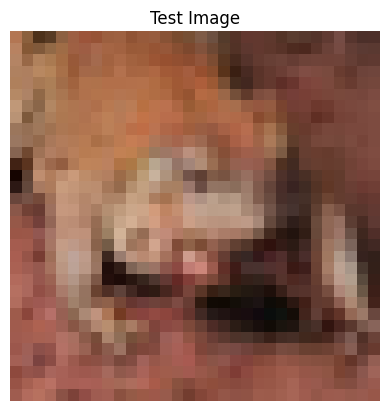

In [ ]:
sample_image = x_test[5]
sample_label = y_test[5]

plt.imshow(sample_image)
plt.title("Test Image")
plt.axis("off")

In [ ]:
img_resized = tf.image.resize(sample_image, (IMG_SIZE, IMG_SIZE))
img_resized = img_resized / 255.0
img_resized = np.expand_dims(img_resized, axis=0)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def show_cam_on_image(model, image, title):

    img = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img_array = np.expand_dims(img, axis=0)

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name="Conv_1_bn"
    )

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + (img.numpy()*255)

    plt.imshow(superimposed.astype("uint8"))
    plt.title(title)
    plt.axis("off")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_179']]
Received: inputs=Tensor(shape=(1, 96, 96, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_341']]
Received: inputs=Tensor(shape=(1, 96, 96, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_505']]
Received: inputs=Tensor(shape=(1, 96, 96, 3))
  warnings.warn(msg)


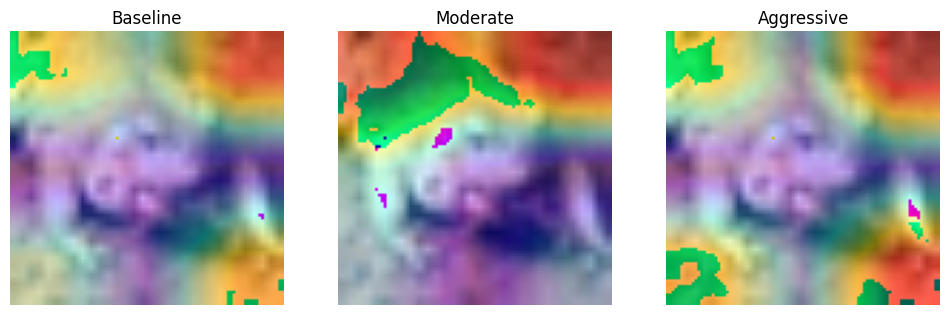

In [ ]:
sample = x_test[5]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
show_cam_on_image(model_baseline, sample, "Baseline")

plt.subplot(1,3,2)
show_cam_on_image(model_mod, sample, "Moderate")

plt.subplot(1,3,3)
show_cam_on_image(model_agg, sample, "Aggressive")

plt.show()

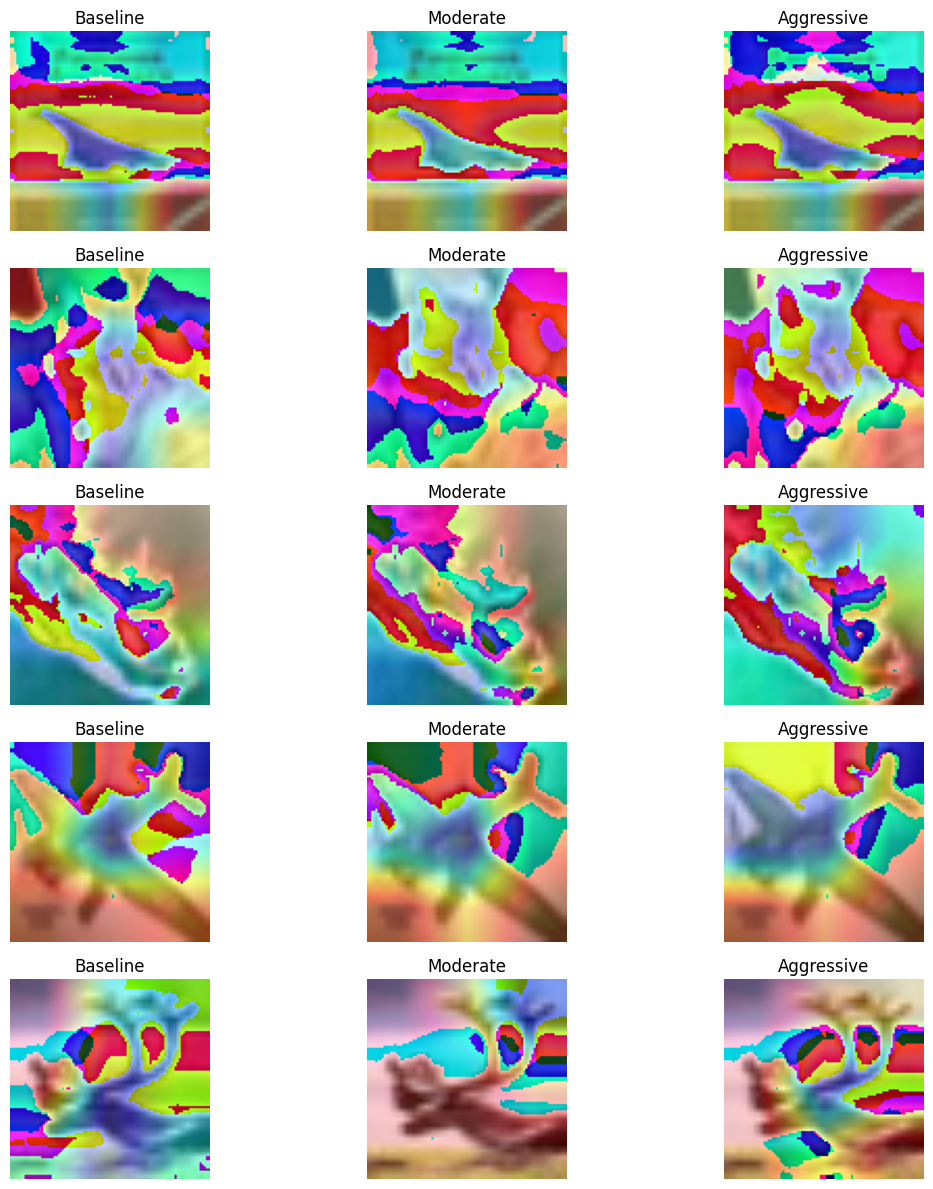

In [ ]:
indices = [3, 8, 15, 27, 40]

plt.figure(figsize=(12,12))

for i, idx in enumerate(indices):

    img = x_test[idx]

    plt.subplot(5,3,3*i+1)
    show_cam_on_image(model_baseline, img, "Baseline")

    plt.subplot(5,3,3*i+2)
    show_cam_on_image(model_mod, img, "Moderate")

    plt.subplot(5,3,3*i+3)
    show_cam_on_image(model_agg, img, "Aggressive")

plt.tight_layout()
plt.show()

In [ ]:
def get_confidence(model, image):

    img = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)

    return np.max(preds)

In [ ]:
def get_confidence(model, image):

    img = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)

    return np.max(preds)

In [ ]:
def rotate_image(image):
    return tf.image.rot90(image)

In [ ]:
idx = 12

img = x_test[idx]
img_rot = rotate_image(img)

base_conf = get_confidence(model_baseline, img)
mod_conf = get_confidence(model_mod, img)
agg_conf = get_confidence(model_agg, img)

base_conf_rot = get_confidence(model_baseline, img_rot)
mod_conf_rot = get_confidence(model_mod, img_rot)
agg_conf_rot = get_confidence(model_agg, img_rot)

print("Baseline:", base_conf, "→", base_conf_rot)
print("Moderate:", mod_conf, "→", mod_conf_rot)
print("Aggressive:", agg_conf, "→", agg_conf_rot)

Baseline: 0.27961788 → 0.5041953
Moderate: 0.31660098 → 0.5284034
Aggressive: 0.30602583 → 0.37802988


In [ ]:
indices = [2,5,8,12,20,33,45,60]

baseline_drops = []
moderate_drops = []
aggressive_drops = []

for idx in indices:

    img = x_test[idx]
    img_rot = rotate_image(img)

    b1 = get_confidence(model_baseline, img)
    b2 = get_confidence(model_baseline, img_rot)

    m1 = get_confidence(model_mod, img)
    m2 = get_confidence(model_mod, img_rot)

    a1 = get_confidence(model_agg, img)
    a2 = get_confidence(model_agg, img_rot)

    baseline_drops.append(abs(b1-b2))
    moderate_drops.append(abs(m1-m2))
    aggressive_drops.append(abs(a1-a2))

In [ ]:
print("Baseline change:", np.mean(baseline_drops))
print("Moderate change:", np.mean(moderate_drops))
print("Aggressive change:", np.mean(aggressive_drops))

Baseline change: 0.28338298
Moderate change: 0.30954632
Aggressive change: 0.28868645


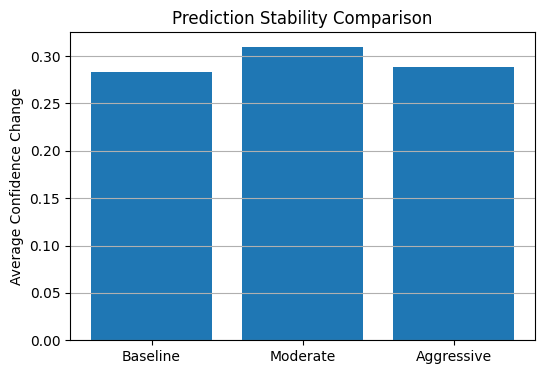

In [ ]:
models = ["Baseline", "Moderate", "Aggressive"]
changes = [
    np.mean(baseline_drops),
    np.mean(moderate_drops),
    np.mean(aggressive_drops)
]

plt.figure(figsize=(6,4))
plt.bar(models, changes)
plt.title("Prediction Stability Comparison")
plt.ylabel("Average Confidence Change")
plt.grid(axis='y')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_baseline.history["accuracy"], label="Baseline")
plt.plot(history_mod.history["accuracy"], label="Moderate Aug")
plt.plot(history_agg.history["accuracy"], label="Aggressive Aug")

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

### Training Configuration

- Optimizer: Adam
- Epochs: 8
- Batch Size: 64
- Backbone: Frozen MobileNetV2
- Input Size: 96×96

## Key Observations

- Baseline training achieved highest accuracy and fastest convergence.
- Augmentation strength influenced prediction stability.
- Strong augmentation may reduce confidence without improving robustness.

This highlights the need to balance augmentation intensity when using transfer learning on limited datasets.